# 📋 Notebook 1 — Data Preparation
**Run once. Saves everything to Google Drive.**

Steps:
1. Mount Google Drive
2. Clone GitHub repo
3. Install dependencies
4. Download IXI T1+T2 (~5GB)
5. Verify BraTS 2021 is on Drive
6. Sanity check: load + display one volume from each dataset

> ⚠️ **No GPU needed for this notebook** — switch to CPU runtime to save compute units.

In [2]:
# ── CELL 1: Mount Drive ────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

DRIVE_ROOT = '/content/drive/MyDrive/atml'
print(f'Drive mounted. Working dir: {DRIVE_ROOT}')

Mounted at /content/drive
Drive mounted. Working dir: /content/drive/MyDrive/atml


In [4]:
# ── CELL 2: Clone repo ─────────────────────────────────────────
import os

GITHUB_URL = 'https://github.com/danielronak/atml-brain-anomaly.git'  # ← UPDATE THIS
REPO_DIR   = '/content/atml-brain-anomaly'

if os.path.exists(REPO_DIR):
    %cd {REPO_DIR}
    !git pull origin main
else:
    !git clone {GITHUB_URL} {REPO_DIR}
    %cd {REPO_DIR}

print('Repo ready.')

Cloning into '/content/atml-brain-anomaly'...
remote: Enumerating objects: 304, done.
remote: Counting objects: 100% (175/175), done.
remote: Compressing objects: 100% (130/130), done.
remote: Total 304 (delta 73), reused 133 (delta 44), pack-reused 129 (from 1)
Receiving objects: 100% (304/304), 96.67 MiB | 42.29 MiB/s, done.
Resolving deltas: 100% (131/131), done.
/content/atml-brain-anomaly
Repo ready.


In [6]:
# ── CELL 3: Install dependencies ──────────────────────────────
!pip install -q monai monai-generative einops nibabel tqdm pyyaml scikit-learn scipy pandas
print('✅ Dependencies installed.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.2/176.2 kB 9.4 MB/s eta 0:00:00
✅ Dependencies installed.


In [ ]:
# ── CELL 4: Download IXI T1+T2 ─────────────────────────────────
import subprocess
from pathlib import Path

IXI_DIR = f'{DRIVE_ROOT}/data/ixi'
Path(IXI_DIR).mkdir(parents=True, exist_ok=True)

!python data/download_ixi.py --out_dir {IXI_DIR}

# Verify
t1_count = len(list(Path(f'{IXI_DIR}/T1').glob('*.nii.gz')))
t2_count = len(list(Path(f'{IXI_DIR}/T2').glob('*.nii.gz')))
print(f'\nIXI T1 scans: {t1_count}')
print(f'IXI T2 scans: {t2_count}')
assert t1_count > 400, 'IXI T1 download may be incomplete'
assert t2_count > 400, 'IXI T2 download may be incomplete'
print('✅ IXI download verified.')

In [8]:
# ── CELL 5: Verify BraTS 2021 ──────────────────────────────────
BRATS_DIR = f'{DRIVE_ROOT}/data/brats2021/BraTS2021_Training_Data'
from pathlib import Path

patients = list(Path(BRATS_DIR).glob('BraTS2021_*'))
print(f'BraTS patients found: {len(patients)}')

if len(patients) < 100:
    print('⚠️  BraTS not found or incomplete.')
    print(f'    Please upload BraTS2021_Training_Data.zip to:')
    print(f'    {DRIVE_ROOT}/data/brats2021/')
    print('    Then run: !unzip ...')
else:
    print(f'✅ BraTS ready ({len(patients)} patients)')

BraTS patients found: 1251
✅ BraTS ready (1251 patients)


/usr/local/lib/python3.12/dist-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)


[IXI] Found 577 paired T1+T2 subjects.
[IXI] Train: 519 | Val: 58


Loading dataset: 100%|██████████| 58/58 [01:33<00:00,  1.62s/it]


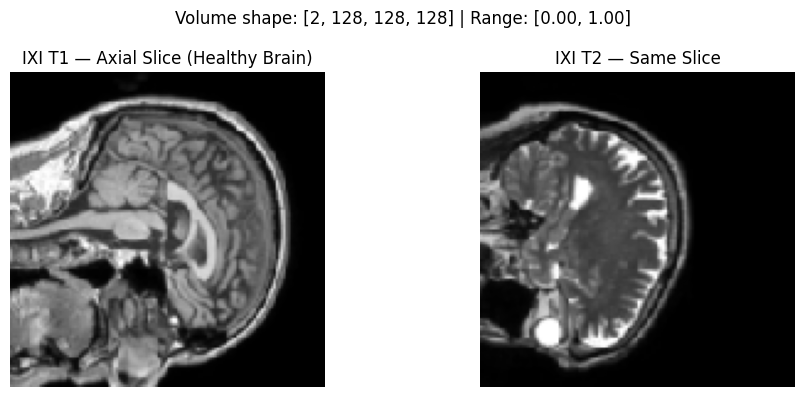

✅ Data pipeline working!


In [10]:
# ── CELL 6: Sanity check — load + display one IXI volume ───────
import yaml, torch, matplotlib.pyplot as plt
import sys; sys.path.insert(0, '/content/atml-brain-anomaly')

with open('configs/default.yaml') as f:
    config = yaml.safe_load(f)

# Update paths to match Drive
config['data']['ixi_dir'] = IXI_DIR
config['data']['brats_dir'] = f'{DRIVE_ROOT}/data/brats2021'
config['data']['checkpoint_dir'] = f'{DRIVE_ROOT}/checkpoints'
config['data']['results_dir'] = f'{DRIVE_ROOT}/results'
config['data']['batch_size'] = 1

from src.data.dataset import get_ixi_dataloaders
train_loader, val_loader = get_ixi_dataloaders(config)

batch = next(iter(train_loader))
vol = batch['image'][0]  # (2, D, H, W) — T1 channel 0, T2 channel 1

s = vol.shape[-1] // 2  # Middle axial slice
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(vol[0, s, :, :].numpy(), cmap='gray')
axes[0].set_title('IXI T1 — Axial Slice (Healthy Brain)')
axes[0].axis('off')
axes[1].imshow(vol[1, s, :, :].numpy(), cmap='gray')
axes[1].set_title('IXI T2 — Same Slice')
axes[1].axis('off')
plt.suptitle(f'Volume shape: {list(vol.shape)} | Range: [{vol.min():.2f}, {vol.max():.2f}]')
plt.tight_layout()
plt.show()
print('✅ Data pipeline working!')

In [9]:
# ── CELL 7: Sanity check — load one BraTS patient ─────────────
from src.data.dataset import get_brats_test_loader

config['data']['n_test_patients'] = 3  # Just check 3 for the sanity check
test_loader = get_brats_test_loader(config)
batch = next(iter(test_loader))

vol  = batch['image'][0]   # (2, D, H, W)
mask = batch['mask'][0]    # (1, D, H, W)

s = vol.shape[-1] // 2
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(vol[0, s, :, :].numpy(), cmap='gray')
axes[0].set_title('BraTS T1 — Tumor Patient')
axes[0].axis('off')
axes[1].imshow(vol[1, s, :, :].numpy(), cmap='gray')
axes[1].set_title('BraTS T2 — Same Patient')
axes[1].axis('off')
axes[2].imshow(mask[0, s, :, :].numpy(), cmap='Reds')
axes[2].set_title('Ground Truth Tumor Mask')
axes[2].axis('off')
plt.tight_layout()
plt.show()
print('✅ BraTS pipeline working!')
print(f'   Volume shape: {list(vol.shape)}')
print(f'   Mask positives (tumor voxels): {mask.sum():.0f}')

NameError: name 'config' is not defined

## ✅ Data Preparation Complete!

Save your Drive paths — you'll need to update `configs/default.yaml` with them:
```
IXI:   /content/drive/MyDrive/atml/data/ixi
BraTS: /content/drive/MyDrive/atml/data/brats2021
```

Next: Open **Notebook 2** (VQ-VAE training) in one runtime  
and **Notebook 3** (Swin-UNET GAN) in a second runtime simultaneously.

In [12]:
# Pull latest code
!git -C /content/atml-brain-anomaly pull origin main

remote: Enumerating objects: 23, done.
remote: Counting objects: 100% (23/23), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 15 (delta 10), reused 12 (delta 7), pack-reused 0 (from 0)
Unpacking objects: 100% (15/15), 10.88 KiB | 795.00 KiB/s, done.
From https://github.com/danielronak/atml-brain-anomaly
 * branch            main       -> FETCH_HEAD
   2fe04fe..fa73b08  main       -> origin/main
Updating 2fe04fe..fa73b08
Fast-forward
 notebooks/02_train_vqvae.ipynb    | 108 ++++++++------
 notebooks/03_train_swin_gan.ipynb | 145 +++++++++---------
 src/models/swin_generator.py      | 247 +++++++++++++++++++++++++-----
 src/models/vqvae.py               | 307 +++++++++++++++++++++++++++++---------
 4 files changed, 591 insertions(+), 216 deletions(-)
